# Lab 3: Gesture Recognition using Convolutional Neural Networks

In this lab you will train a convolutional neural network to make classifications on different hand gestures. By the end of the lab, you should be able to:

1. Load and split data for training, validation and testing
2. Train a Convolutional Neural Network
3. Apply transfer learning to improve your model

Note that for this lab we will not be providing you with any starter code. You should be able to take the code used in previous labs, tutorials and lectures and modify it accordingly to complete the tasks outlined below.

### What to submit

Submit a PDF file containing all your code, outputs, and write-up
from parts 1-5. You can produce a PDF of your Google Colab file by
going to **File > Print** and then save as PDF. The Colab instructions
has more information. Make sure to review the PDF submission to ensure that your answers are easy to read. Make sure that your text is not cut off at the margins. 

**Do not submit any other files produced by your code.**

Include a link to your colab file in your submission.

Please use Google Colab to complete this assignment. If you want to use Jupyter Notebook, please complete the assignment and upload your Jupyter Notebook file to Google Colab for submission. 

## Colab Link

Include a link to your colab file here

Colab Link: 

## Dataset

American Sign Language (ASL) is a complete, complex language that employs signs made by moving the
hands combined with facial expressions and postures of the body. It is the primary language of many
North Americans who are deaf and is one of several communication options used by people who are deaf or
hard-of-hearing. The hand gestures representing English alphabet are shown below. This lab focuses on classifying a subset
of these hand gesture images using convolutional neural networks. Specifically, given an image of a hand
showing one of the letters A-I, we want to detect which letter is being represented.

![alt text](https://www.disabled-world.com/pics/1/asl-alphabet.jpg)

## Part B. Building a CNN [50 pt]

For this lab, we are not going to give you any starter code. You will be writing a convolutional neural network
from scratch. You are welcome to use any code from previous labs, lectures and tutorials. You should also
write your own code.

You may use the PyTorch documentation freely. You might also find online tutorials helpful. However, all
code that you submit must be your own.

Make sure that your code is vectorized, and does not contain obvious inefficiencies (for example, unecessary
for loops, or unnecessary calls to unsqueeze()). Ensure enough comments are included in the code so that
your TA can understand what you are doing. It is your responsibility to show that you understand what you
write.

**This is much more challenging and time-consuming than the previous labs.** Make sure that you
give yourself plenty of time by starting early.

### 1. Data Loading and Splitting [5 pt]

Download the anonymized data provided on Quercus. To allow you to get a heads start on this project we will provide you with sample data from previous years. Split the data into training, validation, and test sets.

Note: Data splitting is not as trivial in this lab. We want our test set to closely resemble the setting in which
our model will be used. In particular, our test set should contain hands that are never seen in training!

Explain how you split the data, either by describing what you did, or by showing the code that you used.
Justify your choice of splitting strategy. How many training, validation, and test images do you have?

For loading the data, you can use plt.imread as in Lab 1, or any other method that you choose. You may find
torchvision.datasets.ImageFolder helpful. (see https://pytorch.org/docs/stable/torchvision/datasets.html?highlight=image%20folder#torchvision.datasets.ImageFolder
) 

In [1]:
import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data.sampler import SubsetRandomSampler
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

In [2]:
# Load data
def get_relevant_indices(dataset, classes, target_classes):
    # Return the indices for datapoints in the dataset that belongs to the desired target classes
    indices = []
    for i in range(len(dataset)): # Check if the label is in the target classes
        label_index = dataset[i][1]
        label_class = classes[label_index]
        if label_class in target_classes:
            indices.append(i)
    return indices

def get_data_loader(target_classes, batch_size):
    # Splits the data into training, validation and testing datasets. Returns data loaders for the three datasets.
    classes = ('A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I')

    transform = transforms.Compose([transforms.Resize((224, 224)),
                transforms.ToTensor()]) # 224x224 pixels
    
    data_path = "C:\\Users\\sissi\\OneDrive\\Desktop\\Code\\APS360\\APS360\\Lab 3\\Lab3_Gestures_Summer"         
    trainset = torchvision.datasets.ImageFolder(data_path, transform = transform) 

    relevant_indices = get_relevant_indices(trainset, classes, target_classes)
    np.random.seed(1000) # Keeps the random shuffle
    np.random.shuffle(relevant_indices)

    # Calculate the cut-off points for a 70%/15%/15% split of the data
    split1 = int(len(relevant_indices) * 0.70)
    split2 = int(len(relevant_indices) * 0.85)
    
    train_indices = relevant_indices[:split1] # 0% to 70% of data
    val_indices = relevant_indices[split1:split2] # 70% to 85%
    test_indices = relevant_indices[split2:] # 85% to 100%

   # Create samplers for all three lists
    train_sampler = SubsetRandomSampler(train_indices)
    val_sampler = SubsetRandomSampler(val_indices)
    test_sampler = SubsetRandomSampler(test_indices)

    # Load data. The sampler ensures they only pull their assigned chunk
    train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, num_workers=1, sampler=train_sampler)
    val_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, num_workers=1, sampler=val_sampler)
    test_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, num_workers=1, sampler=test_sampler)
    return train_loader, val_loader, test_loader, classes

train_loader, val_loader, test_loader, classes = get_data_loader(
    target_classes=["A", "B", "C", "D", "E", "F", "G", "H", "I"], 
    batch_size=1)

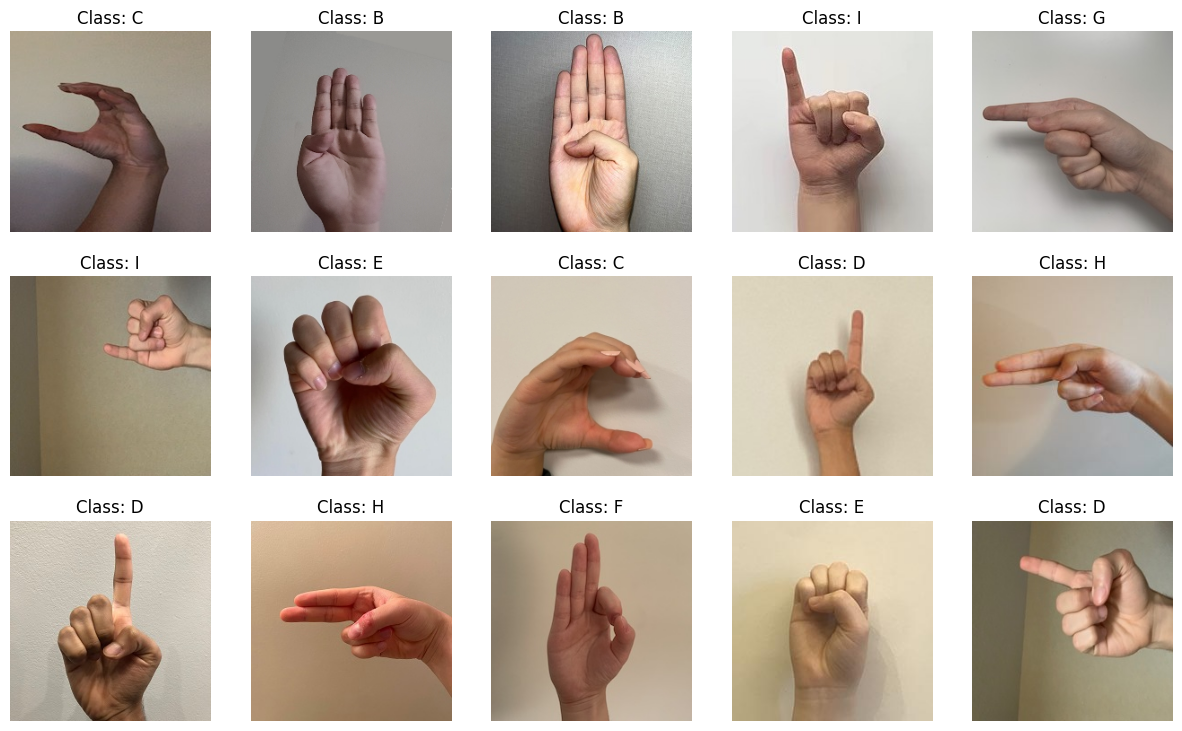

In [3]:
# Visualize data
plt.figure(figsize=(15, 9)) # Set up the canvas size for 3x5 grid

k = 0
for images, labels in train_loader:
    image = images[0] # Batch size is 1 so take the first image
    label_idx = labels[0].item()
    
    img = np.transpose(image.numpy(), [1, 2, 0])  # Place the colour channel at the end
    
    # Plot with 3 rows and 5 columns
    plt.subplot(3, 5, k+1)
    plt.axis('off')
    
    # Show the letter above the image
    plt.title(f"Class: {classes[label_idx]}") 
    plt.imshow(img)

    k += 1
    if k > 14: # Break the loop after 15 images
        break

plt.show()

In [4]:
total_data = len(train_loader) + len(val_loader) + len(test_loader)

print('There are', len(train_loader), 'training images, which is {:.2f} % of the entire dataset.'.format(len(train_loader)/total_data * 100))
print('There are', len(val_loader), 'validation images, which is {:.2f} % of the entire dataset.'.format(len(val_loader)/total_data * 100))
print('There are', len(test_loader), 'test images, which is {:.2f} % of the entire dataset.'.format(len(test_loader)/total_data * 100))

There are 1553 training images, which is 69.99 % of the entire dataset.
There are 333 validation images, which is 15.01 % of the entire dataset.
There are 333 test images, which is 15.01 % of the entire dataset.


### 2. Model Building and Sanity Checking [15 pt]

### Part (a) Convolutional Network - 5 pt

Build a convolutional neural network model that takes the (224x224 RGB) image as input, and predicts the gesture
letter. Your model should be a subclass of nn.Module. Explain your choice of neural network architecture: how
many layers did you choose? What types of layers did you use? Were they fully-connected or convolutional?
What about other decisions like pooling layers, activation functions, number of channels / hidden units?

Output = (W - F + 2P)/S + 1

W = input width/height, F = filter size, P = padding, S = stride

conv1: (224 - 5 + 0)/1 + 1 = 220

pool: 220/2 = 110

conv2: (110 - 5 + 0)/1 + 1 = 106

pool: 106/2 = 53

The above calculations helped me determine the number of channels and hidden units. The output of the convolution layers are 10 channels of 53x53 images. I chose a CNN architecture consisting of 2 convolutional layers, 2 pooling layers, and 2 fully connected layers. The two convolutional layers allow the model to capture both low-level edges and more complex features of the hand gestures. Max pooling is applied to reduce the spatial dimensions of the feature maps which will reduce the number of learnable parameters. This allows the model to train faster. Finally, the extracted features are flattened and passed to the 2 fully-connected layers for the final classification. The ReLU activation function is utilized to introduce non-linearity into the network.

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.name = "cnn"
        
        # Convolution layers
        self.conv1 = nn.Conv2d(3, 5, 5) # (in_channels, out_channels, kernel_size) -> 3 in_channges for RGB, 5 kernels with no padding changes 224x224 to 220x220
        self.pool = nn.MaxPool2d(2, 2) # (kernel_size, stride)
        self.conv2 = nn.Conv2d(5, 10, 5) # in_channels match out_channels of conv1
        
        # Fully connected layers
        self.fc1 = nn.Linear(10 * 53 * 53, 32) # (in_features, out_features), 32 hidden units
        self.fc2 = nn.Linear(32, 9) # in_features matches out_features of fc1, out_features must be 9 for 9 classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 10 * 53 * 53) # Flatten 3D tensor into a 1D line of 28,090 numbers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        # x = x.squeeze(1) # Flatten to batch_size
        
        return x
    
cnn = CNN()

### Part (b) Training Code - 5 pt

Write code that trains your neural network given some training data. Your training code should make it easy
to tweak the usual hyperparameters, like batch size, learning rate, and the model object itself. Make sure
that you are checkpointing your models from time to time (the frequency is up to you). Explain your choice
of loss function and optimizer.

In [6]:
# Obtain accuracy
def get_accuracy(model, batch_size, train=False):
    if train:
        data = train_loader
    else:
        data = val_loader

    correct = 0
    total = 0
    for imgs, labels in torch.utils.data.DataLoader(data, batch_size=batch_size):
        output = model(imgs)
        # Select index with maximum prediction score
        pred = output.max(1, keepdim=True)[1]
        correct += pred.eq(labels.view_as(pred)).sum().item()
        total += imgs.shape[0]
    return correct / total

For the loss function, I used Cross Entropy instead of Binary Classfication since Cross Entropy is good for many classes, especially when the model needs to confidently choose one correct category out of multiple mutually exclusive options. 

I chose the optimizer SGD with momentum 0.9 since it will complete the training faster compared to other options.

In [28]:
#  Train the model
def get_model_name(name, batch_size, learning_rate, epoch):
    path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name,
                                                   batch_size,
                                                   learning_rate,
                                                   epoch)
    return path

def evaluate(net, loader, criterion):
    # Evaluate the network on the validation set
    total_loss = 0.0
    total_err = 0.0
    total_epoch = 0
    for i, data in enumerate(loader, 0):
        inputs, labels = data
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        _, predicted = torch.max(outputs.data, 1)
        corr = predicted != labels
        total_err += int(corr.sum())
        total_loss += loss.item()
        total_epoch += len(labels)
    err = float(total_err) / total_epoch
    loss = float(total_loss) / (i + 1)
    return err, loss

def train_net(net, train_loader, val_loader, batch_size=64, learning_rate=0.01, num_epochs=30):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9)

    train_err = np.zeros(num_epochs)
    train_loss = np.zeros(num_epochs)
    val_err = np.zeros(num_epochs)
    val_loss = np.zeros(num_epochs)

    # Train the network: Loop over the data iterator and sample a new batch of training data
    start_time = time.time()
    for epoch in range(num_epochs): # Loop over the dataset multiple times
        total_train_loss = 0.0
        total_train_err = 0.0
        total_epoch = 0
        for i, data in enumerate(train_loader, 0):
            # Get the inputs
            inputs, labels = data
            # Zero the parameter gradients
            optimizer.zero_grad()
            # Forward pass, backward pass, and optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            # Calculate the statistics
            _, predicted = torch.max(outputs.data, 1)
            corr = predicted != labels
            total_train_err += int(corr.sum())
            total_train_loss += loss.item()
            total_epoch += len(labels)
        train_err[epoch] = float(total_train_err) / total_epoch
        train_loss[epoch] = float(total_train_loss) / (i+1)
        val_err[epoch], val_loss[epoch] = evaluate(net, val_loader, criterion)
        print(("Epoch {}: Train err: {}, Train loss: {} |"+
               "Validation err: {}, Validation loss: {} |").format(
                   epoch + 1,
                   train_err[epoch],
                   train_loss[epoch],
                   val_err[epoch],
                   val_loss[epoch]))
        # Save the current model (checkpoint) to a file
        model_path = get_model_name(net.name, batch_size, learning_rate, epoch)
        torch.save(net.state_dict(), model_path)
    print('Finished Training')
    end_time = time.time()
    elapsed_time = end_time - start_time
    print("Total time elapsed: {:.2f} seconds".format(elapsed_time))
    # Write the train/test loss/err into CSV file for plotting later
    epochs = np.arange(1, num_epochs + 1)
    np.savetxt("{}_train_err.csv".format(model_path), train_err)
    np.savetxt("{}_train_loss.csv".format(model_path), train_loss)
    np.savetxt("{}_val_err.csv".format(model_path), val_err)
    np.savetxt("{}_val_loss.csv".format(model_path), val_loss)


In [21]:
def plot_training_curve(path):
    """ Plots the training curve for a model run, given the csv files
    containing the train/validation error/loss.

    Args:
        path: The base path of the csv files produced during training
    """
    import matplotlib.pyplot as plt
    train_err = np.loadtxt("{}_train_err.csv".format(path))
    val_err = np.loadtxt("{}_val_err.csv".format(path))
    train_loss = np.loadtxt("{}_train_loss.csv".format(path))
    val_loss = np.loadtxt("{}_val_loss.csv".format(path))
    plt.title("Train vs Validation Error")
    n = len(train_err) # number of epochs
    plt.plot(range(1,n+1), train_err, label="Train")
    plt.plot(range(1,n+1), val_err, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend(loc='best')
    plt.show()
    plt.title("Train vs Validation Loss")
    plt.plot(range(1,n+1), train_loss, label="Train")
    plt.plot(range(1,n+1), val_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')
    plt.show()

### Part (c) “Overfit” to a Small Dataset - 5 pt

One way to sanity check our neural network model and training code is to check whether the model is capable
of “overfitting” or “memorizing” a small dataset. A properly constructed CNN with correct training code
should be able to memorize the answers to a small number of images quickly.

Construct a small dataset (e.g. just the images that you have collected). Then show that your model and
training code is capable of memorizing the labels of this small data set.

With a large batch size (e.g. the entire small dataset) and learning rate that is not too high, You should be
able to obtain a 100% training accuracy on that small dataset relatively quickly (within 200 iterations).

In [29]:
import torch.utils.data as data

# Create a tiny loader with 64 images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Package raw math data into (inputs, labels) pairs
debug_dataset = data.TensorDataset(images, labels)
debug_loader = data.DataLoader(debug_dataset, batch_size=64, shuffle=True)

sanity_model = CNN()
train_net(sanity_model, train_loader=debug_loader, val_loader=val_loader, batch_size=64, learning_rate=0.001, num_epochs=100)
sanity_path = get_model_name(sanity_model.name, batch_size=64, learning_rate=0.001, epoch=99)
#plot_training_curve(sanity_path)

correct = 0
total = 0
for imgs, labels in torch.utils.data.DataLoader(debug_dataset, batch_size=64):
    output = sanity_model(imgs)
    #select index with maximum prediction score
    pred = output.max(1, keepdim=True)[1]
    correct += pred.eq(labels.view_as(pred)).sum().item()
    total += imgs.shape[0]
print('Accuracy on batch of 64: ', correct / total)

Epoch 1: Train err: 1.0, Train loss: 2.2301483154296875 |Validation err: 0.9069069069069069, Validation loss: 2.206731546390522 |
Epoch 2: Train err: 1.0, Train loss: 2.218644618988037 |Validation err: 0.9069069069069069, Validation loss: 2.206666842595235 |
Epoch 3: Train err: 1.0, Train loss: 2.2002134323120117 |Validation err: 0.9069069069069069, Validation loss: 2.206668003185375 |
Epoch 4: Train err: 1.0, Train loss: 2.183011054992676 |Validation err: 0.9069069069069069, Validation loss: 2.206734464691208 |
Epoch 5: Train err: 1.0, Train loss: 2.165149450302124 |Validation err: 0.9069069069069069, Validation loss: 2.20693105262321 |
Epoch 6: Train err: 1.0, Train loss: 2.1414849758148193 |Validation err: 0.9069069069069069, Validation loss: 2.207503924498687 |
Epoch 7: Train err: 1.0, Train loss: 2.1109626293182373 |Validation err: 0.8978978978978979, Validation loss: 2.2086772295805783 |
Epoch 8: Train err: 1.0, Train loss: 2.0692362785339355 |Validation err: 0.9009009009009009, 

From the above results, The accuracy is 1.0, showing clear signs of overfitting due to the model "memorizing" the small dataset. Below is the training curve: 

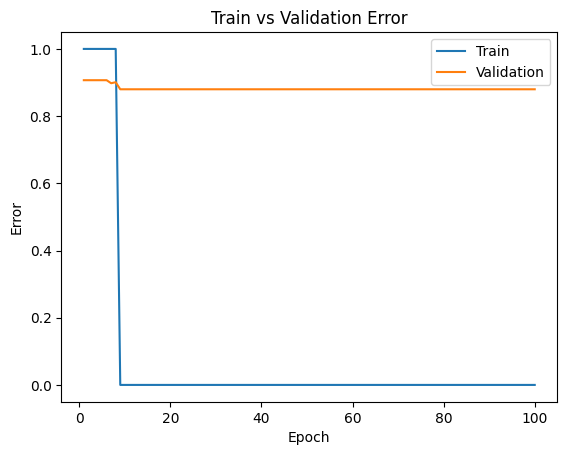

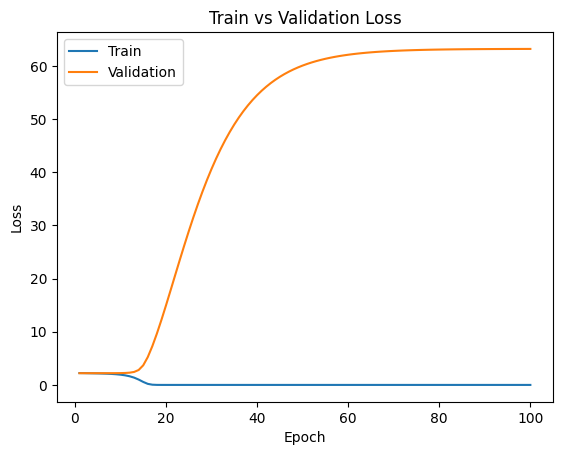

In [30]:
sanity_path = get_model_name(sanity_model.name, batch_size=64, learning_rate=0.001, epoch=99)
plot_training_curve(sanity_path)

### 3. Hyperparameter Search [15 pt]

### Part (a) - 3 pt

List 3 hyperparameters that you think are most worth tuning. Choose at least one hyperparameter related to
the model architecture.

Hyperparameters to tune:

1. batch_size 

2. learning_rate

3. the number of layers in CNN structure

### Part (b) - 5 pt

Tune the hyperparameters you listed in Part (a), trying as many values as you need to until you feel satisfied
that you are getting a good model. Plot the training curve of at least 4 different hyperparameter settings.

1st setting: Default settings

1. batch_size = 64

2. learning_rate = 0.01

3. number of convolution layers in CNN = 2

Epoch 1: Train err: 0.8783000643915003, Train loss: 2.2165692088224778 |Validation err: 0.8888888888888888, Validation loss: 2.254027973782193 |Validation acc: 0.11111111111111116
Epoch 2: Train err: 0.8963296844816484, Train loss: 2.2232047981089034 |Validation err: 0.8798798798798799, Validation loss: 2.2084393107497298 |Validation acc: 0.12012012012012008
Epoch 3: Train err: 0.8821635544108177, Train loss: 2.218625932298625 |Validation err: 0.8798798798798799, Validation loss: 2.2288800903984733 |Validation acc: 0.12012012012012008
Epoch 4: Train err: 0.8866709594333548, Train loss: 2.2191334357970924 |Validation err: 0.8888888888888888, Validation loss: 2.2236431776224315 |Validation acc: 0.11111111111111116
Epoch 5: Train err: 0.8821635544108177, Train loss: 2.2206723348448065 |Validation err: 0.8888888888888888, Validation loss: 2.208358196524886 |Validation acc: 0.11111111111111116
Epoch 6: Train err: 0.892466194462331, Train loss: 2.219152735573817 |Validation err: 0.8858858858

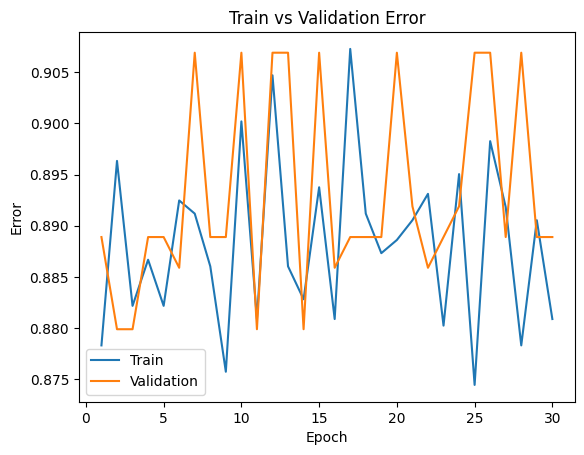

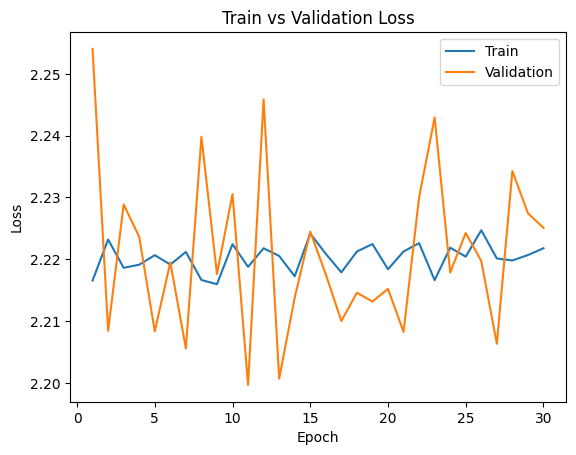

In [27]:
cnn = CNN()
train_net(cnn, train_loader=train_loader, val_loader=val_loader, batch_size=64, learning_rate=0.01, num_epochs=30)
cnn_path = get_model_name(cnn.name, batch_size=64, learning_rate=0.01, epoch=29)
plot_training_curve(cnn_path)

2nd setting: Change batch_size

1. batch_size = 256

2. learning_rate = 0.01

3. number of convolution layers in CNN = 2

Epoch 1: Train err: 0.8982614294913072, Train loss: 2.2171738244454016 |Validation err: 0.9069069069069069, Validation loss: 2.2273346275180668 |
Epoch 2: Train err: 0.8898905344494527, Train loss: 2.2219655654235417 |Validation err: 0.8858858858858859, Validation loss: 2.2375867502825395 |
Epoch 3: Train err: 0.8950418544752092, Train loss: 2.220596656519908 |Validation err: 0.8858858858858859, Validation loss: 2.2167141809835806 |
Epoch 4: Train err: 0.8976175144880876, Train loss: 2.2210300070043543 |Validation err: 0.8918918918918919, Validation loss: 2.2217249612550476 |
Epoch 5: Train err: 0.9008370895041854, Train loss: 2.2223926484009104 |Validation err: 0.8888888888888888, Validation loss: 2.207928492500259 |
Epoch 6: Train err: 0.8789439793947199, Train loss: 2.221174585765512 |Validation err: 0.8858858858858859, Validation loss: 2.2278687141321085 |
Epoch 7: Train err: 0.8834513844172569, Train loss: 2.2138496034773256 |Validation err: 0.8888888888888888, Validation loss: 2.

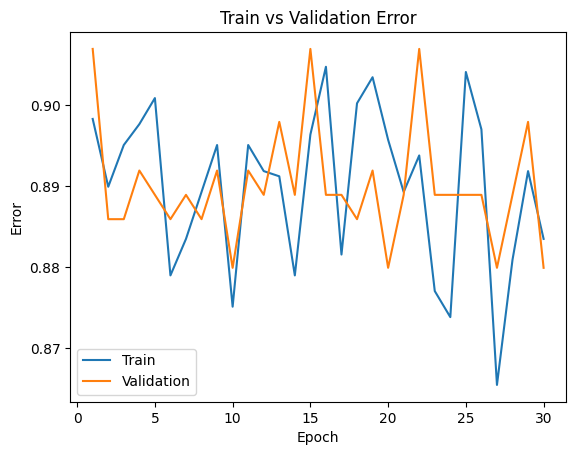

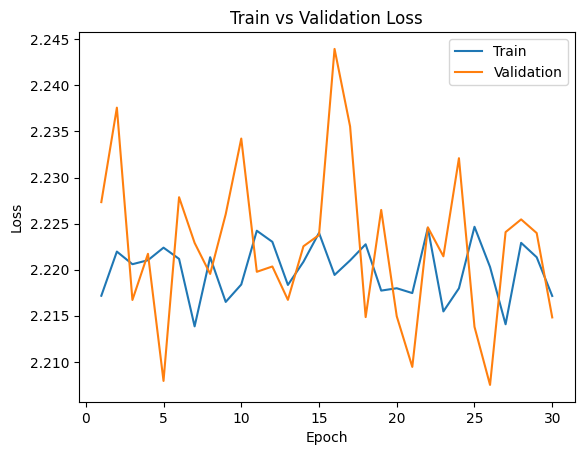

In [31]:
cnn = CNN()
train_net(cnn, train_loader=train_loader, val_loader=val_loader, batch_size=256, learning_rate=0.01, num_epochs=30)
cnn_path = get_model_name(cnn.name, batch_size=256, learning_rate=0.01, epoch=29)
plot_training_curve(cnn_path)

3rd setting: Change learning_rate

1. batch_size = 64

2. learning_rate = 0.001

3. number of convolution layers in CNN = 2

Epoch 1: Train err: 0.8853831294269157, Train loss: 2.2020989990357194 |Validation err: 0.9069069069069069, Validation loss: 2.204698958554425 |
Epoch 2: Train err: 0.8770122343850612, Train loss: 2.1996282588568183 |Validation err: 0.9069069069069069, Validation loss: 2.2025719963394486 |
Epoch 3: Train err: 0.8821635544108177, Train loss: 2.1993791449093005 |Validation err: 0.9069069069069069, Validation loss: 2.2016308407883742 |
Epoch 4: Train err: 0.8931101094655506, Train loss: 2.1992254444498136 |Validation err: 0.9069069069069069, Validation loss: 2.2024956250691914 |
Epoch 5: Train err: 0.8834513844172569, Train loss: 2.1994502251177392 |Validation err: 0.9069069069069069, Validation loss: 2.203377821066 |
Epoch 6: Train err: 0.8821635544108177, Train loss: 2.199536185838757 |Validation err: 0.9069069069069069, Validation loss: 2.202592723004453 |
Epoch 7: Train err: 0.892466194462331, Train loss: 2.1993151920807414 |Validation err: 0.9069069069069069, Validation loss: 2.20433

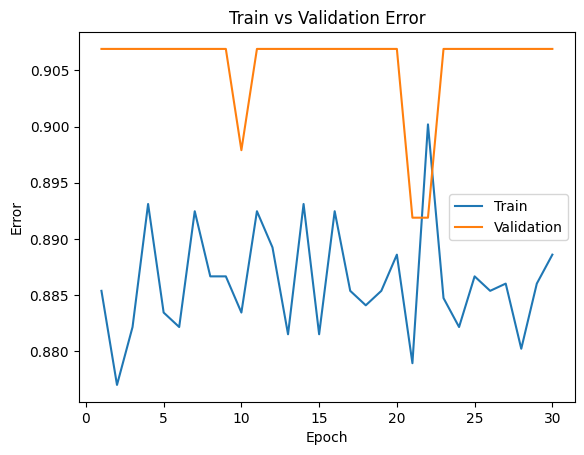

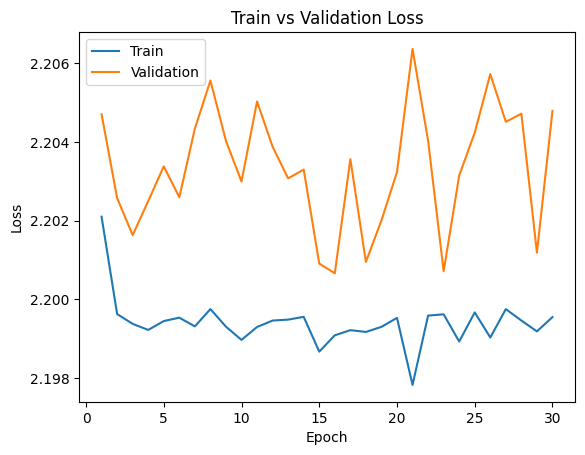

In [32]:
cnn = CNN()
train_net(cnn, train_loader=train_loader, val_loader=val_loader, batch_size=64, learning_rate=0.001, num_epochs=30)
cnn_path = get_model_name(cnn.name, batch_size=64, learning_rate=0.001, epoch=29)
plot_training_curve(cnn_path)

4th setting: Add another convolution layer

1. batch_size = 64

2. learning_rate = 0.01

3. number of convolution layers in CNN = 3

Epoch 1: Train err: 0.8937540244687702, Train loss: 2.223492400230167 |Validation err: 0.8888888888888888, Validation loss: 2.204331952172357 |
Epoch 2: Train err: 0.896973599484868, Train loss: 2.2186178180838274 |Validation err: 0.8798798798798799, Validation loss: 2.2052795307056323 |
Epoch 3: Train err: 0.8886027044430135, Train loss: 2.222882499252683 |Validation err: 0.8888888888888888, Validation loss: 2.2283353071670993 |
Epoch 4: Train err: 0.8956857694784288, Train loss: 2.2208161050092765 |Validation err: 0.8918918918918919, Validation loss: 2.240330943832168 |
Epoch 5: Train err: 0.8943979394719896, Train loss: 2.220382590257039 |Validation err: 0.8798798798798799, Validation loss: 2.228167120758836 |
Epoch 6: Train err: 0.8834513844172569, Train loss: 2.2181589287170196 |Validation err: 0.8858858858858859, Validation loss: 2.2302302941903696 |
Epoch 7: Train err: 0.8802318094011591, Train loss: 2.2187225450182915 |Validation err: 0.8918918918918919, Validation loss: 2.2266

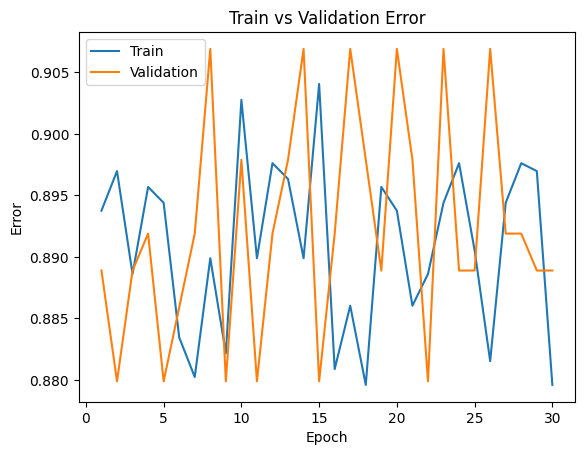

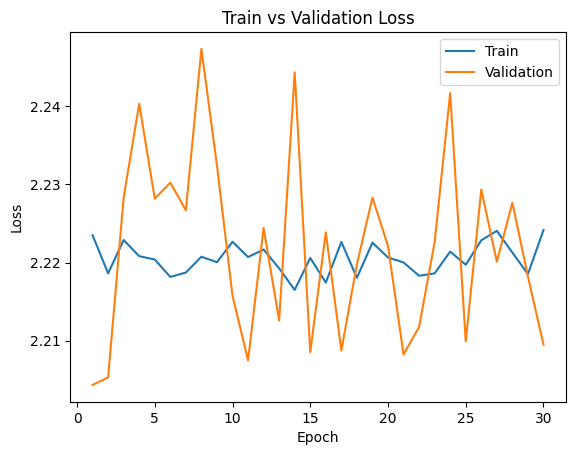

In [33]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.name = "cnn3"
        
        # Convolution layers
        self.conv1 = nn.Conv2d(3, 5, 5)
        self.pool = nn.MaxPool2d(2, 2) 
        self.conv2 = nn.Conv2d(5, 10, 5)
        self.conv3 = nn.Conv2d(10, 20, 5)  # New 3rd layer
        
        # Fully connected layers
        # The new math: 20 channels * 24 height * 24 width = 11,520
        self.fc1 = nn.Linear(20 * 24 * 24, 32) 
        self.fc2 = nn.Linear(32, 9)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x))) # Pass through new layer
        
        x = x.view(-1, 20 * 24 * 24) 
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x
    
cnn3 = CNN()
train_net(cnn3, train_loader=train_loader, val_loader=val_loader, batch_size=64, learning_rate=0.01, num_epochs=30)
cnn3_path = get_model_name(cnn3.name, batch_size=64, learning_rate=0.01, epoch=29)
plot_training_curve(cnn3_path)

5th setting: Improve all paramaters

1. batch_size = 256

2. learning_rate = 0.001

3. number of convolution layers in CNN = 3

Epoch 1: Train err: 0.8873148744365744, Train loss: 2.199451100419432 |Validation err: 0.8888888888888888, Validation loss: 2.2024430376631363 |
Epoch 2: Train err: 0.8892466194462331, Train loss: 2.197842040525585 |Validation err: 0.8888888888888888, Validation loss: 2.201640673227854 |
Epoch 3: Train err: 0.8879587894397939, Train loss: 2.1972174197723233 |Validation err: 0.8888888888888888, Validation loss: 2.2019775551002665 |
Epoch 4: Train err: 0.8847392144236961, Train loss: 2.196561997426531 |Validation err: 0.9069069069069069, Validation loss: 2.201979910647189 |
Epoch 5: Train err: 0.8808757244043787, Train loss: 2.1959333043672618 |Validation err: 0.9069069069069069, Validation loss: 2.201419084279745 |
Epoch 6: Train err: 0.8731487443657437, Train loss: 2.1937619881405803 |Validation err: 0.9069069069069069, Validation loss: 2.1983778627069146 |
Epoch 7: Train err: 0.8177720540888602, Train loss: 2.1821849165005753 |Validation err: 0.8288288288288288, Validation loss: 2.166

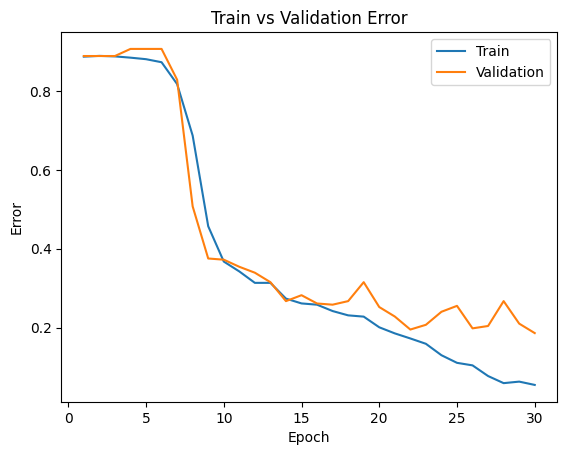

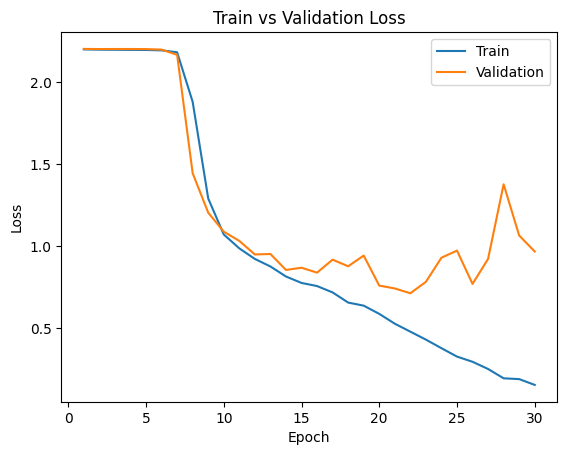

In [35]:
cnn3 = CNN()
train_net(cnn3, train_loader=train_loader, val_loader=val_loader, batch_size=64, learning_rate=0.0001, num_epochs=30)
cnn3_path = get_model_name(cnn3.name, batch_size=64, learning_rate=0.0001, epoch=29)
plot_training_curve(cnn3_path)

### Part (c) - 3 pt
Choose the best model out of all the ones that you have trained. Justify your choice.


The best model has the following parameters:

1. batch_size = 256

2. learning_rate = 0.001

3. number of convolution layers in CNN = 3

### Part (d) - 4 pt
Report the test accuracy of your best model. You should only do this step once and prior to this step you should have only used the training and validation data.

### 4. Transfer Learning [15 pt]
For many image classification tasks, it is generally not a good idea to train a very large deep neural network
model from scratch due to the enormous compute requirements and lack of sufficient amounts of training
data.

One of the better options is to try using an existing model that performs a similar task to the one you need
to solve. This method of utilizing a pre-trained network for other similar tasks is broadly termed **Transfer
Learning**. In this assignment, we will use Transfer Learning to extract features from the hand gesture
images. Then, train a smaller network to use these features as input and classify the hand gestures.

As you have learned from the CNN lecture, convolution layers extract various features from the images which
get utilized by the fully connected layers for correct classification. AlexNet architecture played a pivotal
role in establishing Deep Neural Nets as a go-to tool for image classification problems and we will use an
ImageNet pre-trained AlexNet model to extract features in this assignment.

### Part (a) - 5 pt
Here is the code to load the AlexNet network, with pretrained weights. When you first run the code, PyTorch
will download the pretrained weights from the internet.

In [ ]:
import torchvision.models
alexnet = torchvision.models.alexnet(pretrained=True)

The alexnet model is split up into two components: *alexnet.features* and *alexnet.classifier*. The
first neural network component, *alexnet.features*, is used to compute convolutional features, which are
taken as input in *alexnet.classifier*.

The neural network alexnet.features expects an image tensor of shape Nx3x224x224 as input and it will
output a tensor of shape Nx256x6x6 . (N = batch size).

Compute the AlexNet features for each of your training, validation, and test data. Here is an example code
snippet showing how you can compute the AlexNet features for some images (your actual code might be
different):

In [ ]:
# img = ... a PyTorch tensor with shape [N,3,224,224] containing hand images ...
features = alexnet.features(img)

**Save the computed features**. You will be using these features as input to your neural network in Part
(b), and you do not want to re-compute the features every time. Instead, run *alexnet.features* once for
each image, and save the result.

### Part (b) - 3 pt
Build a convolutional neural network model that takes as input these AlexNet features, and makes a
prediction. Your model should be a subclass of nn.Module.

Explain your choice of neural network architecture: how many layers did you choose? What types of layers
did you use: fully-connected or convolutional? What about other decisions like pooling layers, activation
functions, number of channels / hidden units in each layer?

Here is an example of how your model may be called:

In [ ]:
# features = ... load precomputed alexnet.features(img) ...
output = model(features)
prob = F.softmax(output)

### Part (c) - 5 pt
Train your new network, including any hyperparameter tuning. Plot and submit the training curve of your
best model only.

Note: Depending on how you are caching (saving) your AlexNet features, PyTorch might still be tracking
updates to the **AlexNet weights**, which we are not tuning. One workaround is to convert your AlexNet
feature tensor into a numpy array, and then back into a PyTorch tensor.

In [ ]:
tensor = torch.from_numpy(tensor.detach().numpy())

### Part (d) - 2 pt
Report the test accuracy of your best model. How does the test accuracy compare to Part 3(d) without transfer learning?